# RNN - Modelo Aplicado a demanda energética Alemania

Se desarrolla una RNN para predecir la demanda de consumo. Los datos provienen de SMARD - base de datos que contiene información relacionada al consumo de energía en Alemania.
organizar como estaba, primero todas las vbles, luego se parte en folds/val. Preguntar que pasa en el caso en el que se generan rangos de predicicones distintos

Fuente: https://www.smard.de/en/downloadcenter/download-market-data/?downloadAttributes=%7B"selectedCategory":2,"selectedSubCategory":5,"selectedRegion":"DE","selectedFileType":"CSV","from":1420066800000,"to":1767221999999%7D)''

In [ ]:
# semillas para reproductibilidad
import os
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = "42"

import random
random.seed(42)

import numpy as np
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

# Machine Learning

from tensorflow import keras
from tensorflow.keras import layers, models,optimizers, callbacks
from tensorflow.keras.layers import Dropout

# configuración del entorno
import json
import os
import warnings
import re

import pandas as pd
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

# modelado
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)
# smape - no está definido en sklearn
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError

# visual
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import plotly.graph_objects as go
#plt.style.use("seaborn-v0_8-darkgrid")
#sns.set_palette("viridis")

# optimizacion
import optuna
import optuna.visualization as vis
from optuna.samplers import TPESampler



Se cargan los datos (inicialmente los datos estaban dados en días, lo que se hizo fue tomar la media semanal de las observaciones, dado que se tomaron 10 años de datos. Este proceso ya fue realizado antes de cargar los datos. La fecha mostrada es el lunes de cada semana). El orden de las observaciones está dado en millones

In [2]:
data_demand =  pd.read_csv("../../../data/csv/EC_GER_Weekly.csv")
df_data_demand = pd.DataFrame(data_demand.copy()) # copia del df de precios de cierre como df
df_data_demand["Start date"] = pd.to_datetime(df_data_demand["Start date"]) # conversión a formato fecha
df_data_close = df_data_demand.sort_values(by="Start date", ascending=True) # se ordena por fecha ascendente
df_data_close.head()


,Start date,value
0,2015-01-05,1.240580e+06
1,2015-01-12,1.465239e+06
2,2015-01-19,1.479857e+06
3,2015-01-26,1.516270e+06
4,2015-02-02,1.507588e+06


Se grafican los datos 

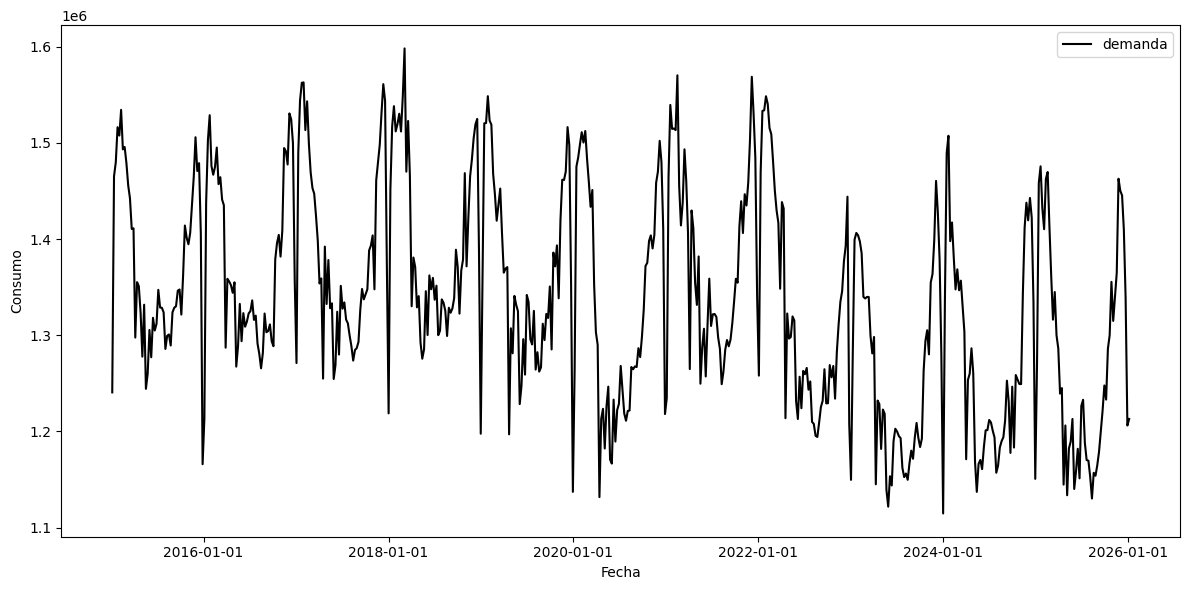

In [3]:
# # se grafican los datos de consumo de forma semanal
plt.figure(figsize=(12,6))
plt.plot(df_data_close["Start date"], df_data_close["value"], label="demanda", color="black")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

Ahora se definen las funciones y variables adicionales derivadas de la serie: 
En esta parte se determinan variables temporales (año, mes trimestre)

In [4]:
# se definen variables generales a tener en cuenta en el df a partir de la fecha: temporalidades: año, mes, día, día de la semana, cuatrimestre
def get_data_times(df, columnName):
    df_copy = df.copy()
    df_copy["year"] = df_copy[columnName].apply(lambda x: x.year)
    df_copy["month"] = df_copy[columnName].apply(lambda x: x.month)
    #df_copy["day"] = df_copy[columnName].apply(lambda x: x.day)
    #df_copy["dayofweek"] = df_copy[columnName].apply(lambda x: x.dayofweek)
    df_copy["quarter"] = df_copy[columnName].apply(lambda x: x.quarter)
    return df_copy

df_data_close_copy = get_data_times(df_data_close, columnName="Start date")
df_data_close_copy.head()

,Start date,value,year,month,quarter
0,2015-01-05,1.240580e+06,2015,1,1
1,2015-01-12,1.465239e+06,2015,1,1
2,2015-01-19,1.479857e+06,2015,1,1
3,2015-01-26,1.516270e+06,2015,1,1
4,2015-02-02,1.507588e+06,2015,2,1


valor semana actual año anterior (definiciones previas - en la versión final NO SE USA)

In [5]:

#df_data_close_copy["value_lag_1y"] = df_data_close_copy["value"].shift(52)
# 52 valores atras (el valor de la semana que se quiere ver un año atras)
df_data_close_copy = df_data_close_copy.dropna()

se toman los rezagos respecto al valor inicial: lags = [1, 2, 3, 4, 8, 12, 26, 52] (recordar que los valores son dados por semana, no por día) - iteraciones previas, en el modelo final NO SE USA

In [6]:
# por eso se toma el valor rezagado de la serie
# función que recibe como argumentos un array con los nombres de las columnas y un array con los rezagos a calcular

def make_df_full_lags(df, lags, variables):
    df_copy = df.copy()
    for variable in variables:
        for lag in lags:
            df_copy[f"{variable}_lag_{str(lag)}"] = df_copy[f"{variable}"].shift(lag)

    return df_copy

variables = [col for col in df_data_close.columns if ("value" in col ) ]
# rezagos por días
# lags = [1,2,7,15,30,60,90]

# rezagos por semanas
lags = [1, 2, 3, 4, 8, 12, 26, 52]
#df_data_close_copy = df_data_close.copy()
#df_data_close_copy = make_df_full_lags(df_data_close_copy, lags, variables).dropna()


#df_data_close[["value", "value_lag_1", "value_lag_2"]]

In [7]:
df_data_close_copy = df_data_close_copy.reset_index(drop=True)
df_data_close_copy.head()

,Start date,value,year,month,quarter
0,2015-01-05,1.240580e+06,2015,1,1
1,2015-01-12,1.465239e+06,2015,1,1
2,2015-01-19,1.479857e+06,2015,1,1
3,2015-01-26,1.516270e+06,2015,1,1
4,2015-02-02,1.507588e+06,2015,2,1


In [8]:
# validación de longitud
len(df_data_close_copy)

575

Cálculo de medias móviles para diversos periodos, que funcionan como variables de entrada adicionales - iteraciones previas, en el modelo final NO SE USA

In [9]:
# medias móviles de los precios de cierre: se crea una función para que tome las medias móviles de 
# 7,15,30,60,90 días. Se toman estas medias moviles para los precios anteriores
def make_df_full_averages(df, vars_list, ma_periods, dropna=True, overwrite=False):
    df_copy = df.copy()

    # solo permitir variables originales (sin _lag_ ni _ma_)
    clean_vars = [
        v for v in vars_list
        if v in df_copy.columns and "_lag_" not in v and "_ma_" not in v
    ]

    missing = [v for v in vars_list if v not in df_copy.columns]
    if missing:
        raise ValueError(f"Estas columnas no existen: {missing}")

    for variable in clean_vars:
        for period in ma_periods:
            name = f"{variable}_ma_{period}"

            if (name in df_copy.columns) and (not overwrite):
                continue

            df_copy[name] = (
                df_copy[variable]
                .shift(1)  # evita leakage, dado que se toma desde la posición t-1 hacia atras
                .rolling(window=period)
                .mean()
            )

    if dropna:
        df_copy = df_copy.reset_index(drop=True).dropna()

    return df_copy

# periodos para ma por días
# ma_periods = [7, 15, 30, 60, 90]

# periodos ma por semanas
ma_periods = [
    2, # dos semanas desde la anterior
    3, # tres semanas desde la anterior
    4, # 4 semanas desde la anterior (desde la ultima semana, un mes)
    8, # 8 semanas desde la anterior (desde la ultima semana, dos meses)
    12, # 12 semanas desde la anterior (desde la ultima semana, tres meses)
    16, # 16 semanas desde la anterior (desde la última semana, 4 meses)
    26, # 16 semanas desde la anterior (desde la última semana, 4 meses)
]

#df_data_close_copy = make_df_full_averages(
#    df_data_close_copy,
#    vars_list=variables,
#    ma_periods=ma_periods
#)

#df_data_close_copy = df_data_close


In [10]:
# se valida que no hayan variables adicionales en el df a usar para entrenar la rnn
df_data_close_copy.head()

,Start date,value,year,month,quarter
0,2015-01-05,1.240580e+06,2015,1,1
1,2015-01-12,1.465239e+06,2015,1,1
2,2015-01-19,1.479857e+06,2015,1,1
3,2015-01-26,1.516270e+06,2015,1,1
4,2015-02-02,1.507588e+06,2015,2,1


In [11]:
len(df_data_close_copy)

575

Se seleccionan las variables que serán las variables de entrada del modelo

In [12]:
# selecicon de variables - se muestran todas las variables, se pasa el valor target a modo de valor previo para realizar la predicción
target = ["value"]
features = [col for col in df_data_close_copy.columns if (col != "Start date")] 
            #if (col not in target and col != "Start date")]     
features 

['value', 'year', 'month', 'quarter']

Ahora se crea la función que creará las ventanas con los rezagos para ingresar en la red. Para que la RNN reciba los datos como un tensor de orden 3, la función crea un dataset para los datos de entrenamiento de la RNN.

In [13]:
# create_dataset es una función que genera los datos de entrada X y los datos de salida y
# se crea una ventana de datos de tamaño 1 (pero este será un hiperparámetro de la red) sobre los precios y se almacena
# el próximo precio como objetivo. El array X es redimensionado como un array 3D como lo requiere la RNN:
# [samples, time_steps, features] 

# def create_dataset(data, time_step=1):
#    X, y = [], [] # se crean dos arrays vacíos que devolverán los datos separados por ventanas
#    for i in range(len(data) - time_step):
#        arr_2_add = data[i : (i + time_step), :]
#        # print(len(arr_2_add))
#        X.append(arr_2_add)
#        y.append(data[i + time_step, 0])
#    return np.array(X), np.array(y)

# Versión final 
def create_dataset(data, target_array, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i : (i + time_step), :])
        y.append(target_array[i + time_step])
    return np.array(X), np.array(y)

X, y = create_dataset(
    df_data_close_copy[features].values,
    df_data_close_copy[target].values.ravel(), time_step=4
)
np.set_printoptions(suppress=True, precision=2)
X[0]

array([[1240580.1 ,    2015.  ,       1.  ,       1.  ],
       [1465239.43,    2015.  ,       1.  ,       1.  ],
       [1479857.36,    2015.  ,       1.  ,       1.  ],
       [1516269.64,    2015.  ,       1.  ,       1.  ]])

In [14]:
pd.set_option( 'display.float_format' , '{:.2f}' . format ) 
df_data_close_copy.head(2)

,Start date,value,year,month,quarter
0,2015-01-05,1240580.10,2015,1,1
1,2015-01-12,1465239.43,2015,1,1


función de creación de la RNN, que se usa para la optimización y la instancia del mejor modelo (crear la RNN de forma paramétrica)

In [15]:
# validación de longitudes (la llongitud de X cambia por el parametro time_steps, para el primer array se toma la cantidad de elementos dados por este
# parametro)
print(f"len x: {len(X)}")
print(f"len df data close: {len(df_data_close_copy)}")

len x: 571
len df data close: 575


In [16]:
# input_timesteps: numero de rezagos
# n_features: numero de características (variables exogenas + variables objetivo)
# units: numero de unidades de la capa recurrente
# lr: tasa de aprendizaje
def build_rnn(input_timesteps, n_features, units, lr,  dropout_rate=0.2, recurrent_dropout_rate=0.1):
    model = models.Sequential() # se inicializa el modelo
    model.add(layers.Input(shape=(input_timesteps, n_features))) # se añade la capa de entrada, son las n_features
    # cada una con dimensión input_timesteps
    model.add(layers.SimpleRNN(
        units=units, 
        activation="tanh", # función de activación8POSIBLE PREGUNT: POR QUE SE ESCOGIO ESA FUNCIOND E ACTIVACION
        stateful=False,
        dropout=dropout_rate, # regularización en las entradas
        recurrent_dropout=recurrent_dropout_rate  # regularización en las conexiones internas
        )
    ) # se añade la capa RNN con las unidades y función de activación tanh
    model.add(layers.Dense(units=1, activation="linear")) # se añade la capa densa de salida con una neurona y función de activación lineal
    model.compile(
        optimizer = optimizers.Adam(learning_rate=lr), # se compila el modelo con el optimizador Adam y la tasa de aprendizaje lr
        loss = "mean_squared_error" # se utiliza el error cuadrático medio como función de pérdida
    )

    return model
# el modelo tiene una neurona de salida. SIn embargo, al usar la definición por ventanas, se toman secuencias de una longitud que tienen 
# como etiqueta otro valor, por lo que el resultado es una neurona pero devuelve un vector

división folds/val: Se separan los datos en los conjuntos train y test para validar el rendimiento del modelo final mediante datos no vistos. Se toma el 90% del total de datos como conjunto de entrenamiento y el 10% restante como conjunto de validación. Se realiza dicha división y se grafica

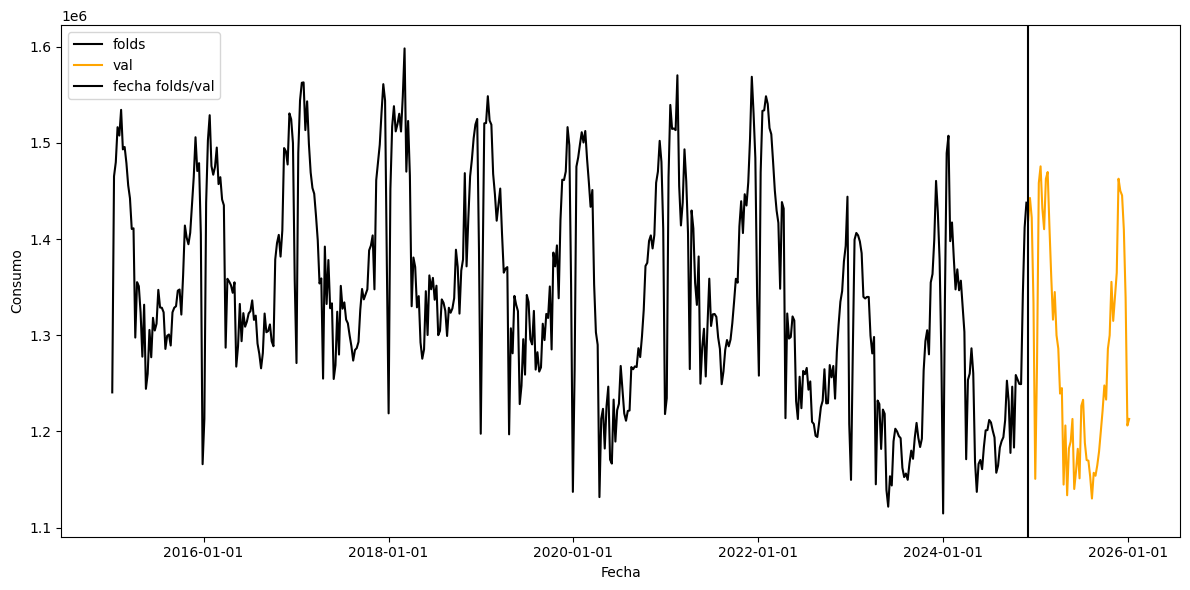

In [17]:
percentage = 0.9
folds_data_size = int(len(df_data_close_copy) * percentage)
folds_data = df_data_close_copy[:folds_data_size]
val_data = df_data_close_copy[folds_data_size:]
start_val_data = val_data["Start date"].values[0]
len(val_data)

# gráfica división folds/val
plt.figure(figsize=(12,6))
plt.plot(folds_data["Start date"], folds_data["value"], label="folds", color="black")
plt.plot(val_data["Start date"], val_data["value"], label="val", color="orange")
plt.axvline(start_val_data, color="black", label="fecha folds/val")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

# esta parte es para que las fechas en el eje x se vean mejor
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.AutoDateLocator()) # se ajusta el espaciado de las fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # se formatea la fechas
#plt.grid(True)
plt.tight_layout()# se ajusta el layout para que no se corten los elementos
plt.show()

In [18]:
# longitud del conjunto de datos trainG y testf
print(len(folds_data))
print(len(val_data))

517
58


Visualización de los folds a implementar

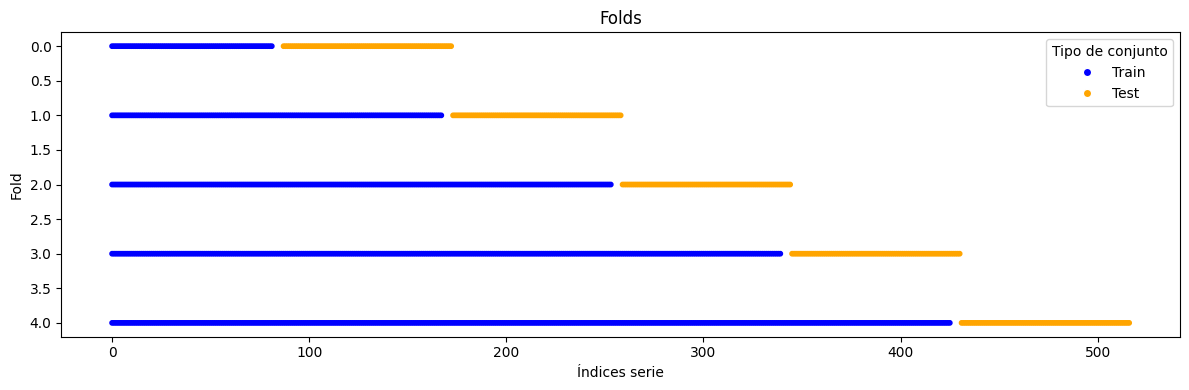

In [19]:
# visualizacion de los folds 
# se muestra de forma visual como funcionan los folds
# si no se define el tamaño de test, en la primera iteracion se toma igual cantidad de datos para train que para test
# por eso se toman los folds de prueba como de la longitud de datos de validación

gap = 5 # distancia (cantidad de observaciones) que se deja entre train y test
tscv = TimeSeriesSplit(
    n_splits=5,
    #test_size=size_test, 
    gap=gap
)

folds, indexes, types = [], [], []

for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    folds.extend([fold_idx] * len(train_idx)) 
    indexes.extend(train_idx)
    types.extend(['Train'] * len(train_idx))

    folds.extend([fold_idx] * len(test_idx))
    indexes.extend(test_idx)
    types.extend(['Test'] * len(test_idx))

# figura con matplotlib
colors = ['blue' if t == 'Train' else 'orange' for t in types]

plt.figure(figsize=(12, 4))
plt.scatter(indexes, folds, c=colors, s=10)

# leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=6, label='Train'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=6, label='Test')
]
plt.legend(handles=legend_elements, title="Tipo de conjunto")

plt.title('Folds')
plt.xlabel('Índices serie')
plt.ylabel('Fold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



In [20]:
# figura con plotly
# fig = go.Figure()
# 
# # data train
# fig.add_trace(go.Scatter(
#     x=indexes, y=folds,
#     mode='markers',
#     marker=dict(color=['blue' if t == 'Train' else 'orange' for t in types], size=6),
#     text=types,
#     hovertemplate='Index: %{x}<br> Fold: %{y}<br> Tipo: %{text}<extra></extra>'
# ))
# 
# fig.update_layout(
#     title='Folds',
#     xaxis_title='Indices serie',
#     yaxis_title='Fold',
#     yaxis=dict(autorange='reversed'),
#     legend_title='Tipo de conjunto',
#     template='plotly_white',
#     height=400
# )
#fig.show()


# Función de optimización

Mediante el uso de Optuna (una librería basada en técnicas de optimización bayesiana secuencial) se define una función de optimización que utiliza validación cruzada temporal para minimizar una métrica de error (en este caso, el MAPE*).

La función está dada de la siguiente forma: primero, se definen los hiperparámetros de la rnn: número de rezagos, unidades recurrentes, tasa de aprendizaje, tamaño de lote y número de épocas.   Para cada uno de estos parámetros se especifican rangos o conjuntos discretos de valores que Optuna explorará con el fin de encontrar la combinación que minimice el error promedio.

Posteriormente, se inicializan listas que almacenarán las métricas de evaluación obtenidas en cada fold (MAPE, MAE y RMSE).  
Durante cada iteración del proceso de validación cruzada, se realiza lo siguiente:
0. se definen los conjuntos train/test de acuerdo con ese fold
1. Se instancia un nuevo modelo RNN con el conjunto de hiperparámetros seleccionados para el trial actual.  
2. Se entrena el modelo sobre el conjunto de entrenamiento definido para ese fold.  
3. Se evalúa el modelo sobre el conjunto de prueba correspondiente, calculando las métricas de error.  

Este proceso se repite para los *k* folds (en este caso, 5), produciendo un conjunto de errores por fold:

- Fold₁ → MAPE₁  
- Fold₂ → MAPE₂  
- Fold₃ → MAPE₃  
- Fold₄ → MAPE₄  
- Fold₅ → MAPE₅  

Así se obtiene el MAPE promedio de los cinco folds:$$ \text{MAPE}_{prom} = \frac{1}{5} \sum_{i=1}^{5} \text{MAPE}_i $$

Este valor se devuelve como resultado de la función objetivo, y representa el desempeño promedio del modelo bajo ese conjunto de hiperparámetros. Optuna repite este proceso en múltiples trials, cada uno con una combinación diferente de hiperparámetros, y selecciona el conjunto que minimiza el MAPE promedio obtenido.


visualización de los datos: se valida la forma previa de los datos transofrmados que se usarán en el proceso de optimización

In [21]:
# validación arrays de features y target
data_raw_full = folds_data[features].values.astype(np.float32)
target_raw_full = folds_data[target].values.astype(np.float32)
data_raw_full

array([[1240580.1,    2015. ,       1. ,       1. ],
       [1465239.4,    2015. ,       1. ,       1. ],
       [1479857.4,    2015. ,       1. ,       1. ],
       ...,
       [1343062.5,    2024. ,      11. ,       4. ],
       [1411930.6,    2024. ,      11. ,       4. ],
       [1437810. ,    2024. ,      11. ,       4. ]], dtype=float32)

In [22]:
X_fold, y_fold = create_dataset(
        data_raw_full,
        target_raw_full,
        2
    )
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_fold)):
    X_train_raw = X_fold[train_idx]
    y_train_raw = y_fold[train_idx].reshape(-1,1)
    
X_train_raw[0]

array([[1240580.1,    2015. ,       1. ,       1. ],
       [1465239.4,    2015. ,       1. ,       1. ]], dtype=float32)

In [23]:
folds_data

,Start date,value,year,month,quarter
0,2015-01-05,1240580.10,2015,1,1
1,2015-01-12,1465239.43,2015,1,1
2,2015-01-19,1479857.36,2015,1,1
3,2015-01-26,1516269.64,2015,1,1
4,2015-02-02,1507587.54,2015,2,1
...,...,...,...,...,...
512,2024-10-28,1249366.54,2024,10,4
513,2024-11-04,1249164.86,2024,11,4
514,2024-11-11,1343062.54,2024,11,4
515,2024-11-18,1411930.64,2024,11,4


In [24]:
y_train_raw[0]

array([1479857.4], dtype=float32)

validacion previa: se examina que conjuntos train y test de los folds no compartan valores, para evitar data leakage. Se valida que el último índice del conjunto de entrenamiento mas el gap definido antes no sea mayor o igual que el primer índice del conjunto de test de cada fold, así se valida que no hay solapamiento de datos 

In [25]:
# se toma el último índice del conjunto de indices train de cada fold, se suma el gap y se compara con el primer índice del conjunto de pruebas
# de cada fold
for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(folds_data)):
    print(f"último índice de train de fold {fold_idx} + gap: {train_idx[-1] + gap}. Primer indice de test de fold {fold_idx}: {test_idx[0]}")

último índice de train de fold 0 + gap: 86. Primer indice de test de fold 0: 87
último índice de train de fold 1 + gap: 172. Primer indice de test de fold 1: 173
último índice de train de fold 2 + gap: 258. Primer indice de test de fold 2: 259
último índice de train de fold 3 + gap: 344. Primer indice de test de fold 3: 345
último índice de train de fold 4 + gap: 430. Primer indice de test de fold 4: 431


In [26]:
# función objetivo
def objective(trial):
    # parametros de la red
    #input_timesteps = trial.suggest_categorical('input_timesteps', [1,2,7,15,30,60,90]) # ventana temporal /rezagos
    input_timesteps = trial.suggest_categorical('input_timesteps', [1,2,4,8,12,26,52]) # ventana temporal /rezagos (ventanas históricas de datos)
    #input_timesteps = trial.suggest_categorical('input_timesteps', [1]) # ventana temporal /rezagos
    units = trial.suggest_int("units", 32, 256, step=32)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch_size', [16,32,64,128])
    epochs = trial.suggest_int('epochs', 40, 120)
    dropout = trial.suggest_float('dropout_rate', 0.0, 0.3)
    recurrent_dropout = trial.suggest_float('recurrent_dropput_rate', 0.0, 0.3)

    # redimensionado de folds_data
    
    # Datos base reordenados como matriz de tamaño p x q 
    data_raw = folds_data[features].values.astype(np.float32)
    target_raw = folds_data[target].values.astype(np.float32).ravel()

    # Construcción de ventanas
    X_fold, y_fold = create_dataset(
        data_raw,
        target_raw,
        input_timesteps
    )

    # se almacenan las metricas por fold
    mapes, maes, rmses, smapes = [], [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X_fold)):

        # reproductibilidad en cada fold
        tf.keras.backend.clear_session()
        tf.random.set_seed(42)
        np.random.seed(42)

        # escalado por fold
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()

        # datos de entrenamiento por fold
        X_train_raw = X_fold[train_idx]
        y_train_raw = y_fold[train_idx].reshape(-1,1)

        # fold de test
        X_test_raw = X_fold[test_idx]
        y_test_raw = y_fold[test_idx].reshape(-1,1)

        # REescalado
        X_train = scaler_X.fit_transform(
            X_train_raw.reshape(-1, X_fold.shape[2])
        ).reshape(X_train_raw.shape)


        X_test = scaler_X.transform(
            X_test_raw.reshape(-1, X_fold.shape[2])
        ).reshape(X_test_raw.shape)

        y_train = scaler_y.fit_transform(y_train_raw)
        y_test = scaler_y.transform(y_test_raw)

        n_features = X_train.shape[-1]

        # se onstruye el modelo
        model = build_rnn(
            input_timesteps,
            n_features,
            units,
            lr,
            dropout,
            recurrent_dropout
        )

        # se fija el modelo
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch,
            shuffle=False,
            verbose=0
        )

        # predicción sobre el fold de prueba
        y_pred_scaled = model.predict(X_test, verbose=0)
        y_pred = scaler_y.inverse_transform(y_pred_scaled)
        y_true = y_test_raw

        # Métricas de error 
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        smape_calc = MeanAbsolutePercentageError(symmetric=True)
        smape = smape_calc(y_true, y_pred)

        # se añaden a los arrays
        mapes.append(mape)
        maes.append(mae)
        rmses.append(rmse)
        smapes.append(smape)

        # se guarda registro del trial como atributo de usuario del study para poder consultarlo luego
        trial.set_user_attr(f"fold_{fold_idx + 1}", {"mae": mae, "mape": mape, "rmse": rmse, "smape": smape})
        # se reporta el valor de la media de los mapes
        trial.report(np.mean(mapes), step=fold_idx)

    
    # Función objetivo
    mean_mape = np.mean(mapes)
    mean_smape = np.mean(smapes)
    mean_rmse = np.mean(rmses)
    mean_mae = np.mean(maes)

    trial.set_user_attr("mape_mean", mean_mape)
    trial.set_user_attr("mae_mean", mean_mae)
    trial.set_user_attr("rmse_mean", mean_rmse)
    trial.set_user_attr("smape_mean", mean_smape)
    
    
    return float(mean_mape) #+ 0.25 * std_mape)
    
# se ejecuta la optimización con Optuna
print("Optimización con Optuna")
# se crea el caso de estudio, con el objetivo y la función a minimizar
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50)


[I 2026-05-02 20:14:22,141] A new study created in memory with name: no-name-4eecec77-3bbd-4731-b40a-1fa185ce1878


Optimización con Optuna



[I 2026-05-02 20:15:16,401] Trial 0 finished with value: 0.04684256762266159 and parameters: {'input_timesteps': 2, 'units': 224, 'lr': 0.0015930522616241021, 'batch_size': 64, 'epochs': 57, 'dropout_rate': 0.05454749016213018, 'recurrent_dropput_rate': 0.055021352956030146}. Best is trial 0 with value: 0.04684256762266159.
[I 2026-05-02 20:16:03,955] Trial 1 finished with value: 0.04747268483042717 and parameters: {'input_timesteps': 12, 'units': 96, 'lr': 0.000816845589476017, 'batch_size': 16, 'epochs': 43, 'dropout_rate': 0.1822634555704315, 'recurrent_dropput_rate': 0.051157237106187456}. Best is trial 0 with value: 0.04684256762266159.
[I 2026-05-02 20:16:53,187] Trial 2 finished with value: 0.046306225657463077 and parameters: {'input_timesteps': 4, 'units': 128, 'lr': 0.00017541893487450815, 'batch_size': 64, 'epochs': 93, 'dropout_rate': 0.09351332282682329, 'recurrent_dropput_rate': 0.15602040635334324}. Best is trial 2 with value: 0.046306225657463077.
[I 2026-05-02 20:17:37

en cada trial se devuelven datos relacionados con
- valor mape mínimo
- conjunto de hiperparámetros
- trial que ha dejado menor mape (o métrica seleccionada) hasta el momento
- errores promedio por fold (mape, mae, rmse, smape)

In [27]:
# mejor conjunto de hiperparámetros
study.best_params

{'input_timesteps': 52,
 'units': 96,
 'lr': 0.0011178917527043502,
 'batch_size': 32,
 'epochs': 120,
 'dropout_rate': 0.033268680966822006,
 'recurrent_dropput_rate': 0.1041403772456473}

información de los trials

In [28]:
# info de los trials 
# se extraen los trials
trials = study.get_trials()
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs
    print(attrs)

{'fold_1': {'mae': 76650.375, 'mape': 0.05270756036043167, 'rmse': 93576.7875490498, 'smape': 0.0546790286898613}, 'fold_2': {'mae': 45727.875, 'mape': 0.03391188383102417, 'rmse': 59521.135473040165, 'smape': 0.03367234766483307}, 'fold_3': {'mae': 56452.2890625, 'mape': 0.043264225125312805, 'rmse': 68898.35574235425, 'smape': 0.04239781200885773}, 'fold_4': {'mae': 50259.73046875, 'mape': 0.03777708858251572, 'rmse': 63355.71702695819, 'smape': 0.03742944449186325}, 'fold_5': {'mae': 80448.5546875, 'mape': 0.06655208021402359, 'rmse': 92515.5308907645, 'smape': 0.06387561559677124}, 'mape_mean': 0.04684256762266159, 'mae_mean': 61907.76484375, 'rmse_mean': 75573.50533643339, 'smape_mean': 0.046410849690437316}
{'fold_1': {'mae': 71460.9375, 'mape': 0.05107113718986511, 'rmse': 90555.47691884793, 'smape': 0.05099252983927727}, 'fold_2': {'mae': 44416.3828125, 'mape': 0.033031780272722244, 'rmse': 60143.54668624058, 'smape': 0.03258829563856125}, 'fold_3': {'mae': 50751.21484375, 'map

creacion df errores por fold y por trial

In [29]:
# creación del df a nivel de registro
# el esquema del df se infiere a partir de las claves almacenadas 
# en cada registro (las claves no varían)
rows = [] # se usará para guardar la info a nivel de registro
for trial in trials:
    trial_number = trial.number # número de trial: trial 1, 2,...
    attrs = trial.user_attrs # los valores de las métricas se definen en la función como 
    # un atributo de usuario, definido como un diccionario
    # se recorren ahora las claves y los valores de cada diccionario
    for key, value in attrs.items():
        if key.startswith("fold_") and isinstance(value, dict): 
            # se examina si cada clave del diccionario empieza con fold_. Recordar que en la función
            # se guardó un diccionario con el nombre fold_i_metrics, que guarda la info de cada fold y cada trial.
            # Se mira entonces si la clave es de esa forma y si el valor de esa clave es un diccionario
            rows.append({
                "trial": trial_number,
                "fold": key[-1],
                "mape": value.get("mape"),
                "mae": value.get("mae"),
                "rmse": value.get("rmse"),
                "smape": value.get("smape")
            }) 
df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values(by="mape")
df_metrics.head()

,trial,fold,mape,mae,rmse,smape
244,48,5,0.02,28171.62,37425.09,0.02
234,46,5,0.02,31108.67,44086.40,0.02
224,44,5,0.03,31375.14,41415.39,0.02
64,12,5,0.03,32870.55,46537.33,0.03
243,48,4,0.03,34323.21,47896.20,0.03


In [30]:
# descripción general del df de métricas
df_stats = df_metrics.describe()
df_stats[["mape", "mae", "rmse", "smape"]]

,mape,mae,rmse,smape
count,250.00,250.00,250.00,250.00
mean,0.04,55144.24,69297.03,0.04
std,0.01,13043.66,14191.67,0.01
min,0.02,28171.62,37425.09,0.02
25%,0.03,45576.95,59593.69,0.03
50%,0.04,52456.63,66766.90,0.04
75%,0.05,63103.68,77253.59,0.05
max,0.08,100297.34,116712.59,0.07


### Distribución por errores promedio
se muestran las distribuciones de los errores promedio por trial

In [31]:
df_metrics_avg = df_metrics.copy()
df_metrics_avg = df_metrics_avg.groupby(
    "trial", as_index=False 
)[["mape", "mae", "rmse", "smape"]].mean()
df_metrics_avg.head()

,trial,mape,mae,rmse,smape
0,0,0.05,61907.76,75573.51,0.05
1,1,0.05,62153.36,77487.19,0.05
2,2,0.05,61138.51,75387.38,0.05
3,3,0.06,75196.45,89875.46,0.06
4,4,0.04,58202.05,73334.45,0.04


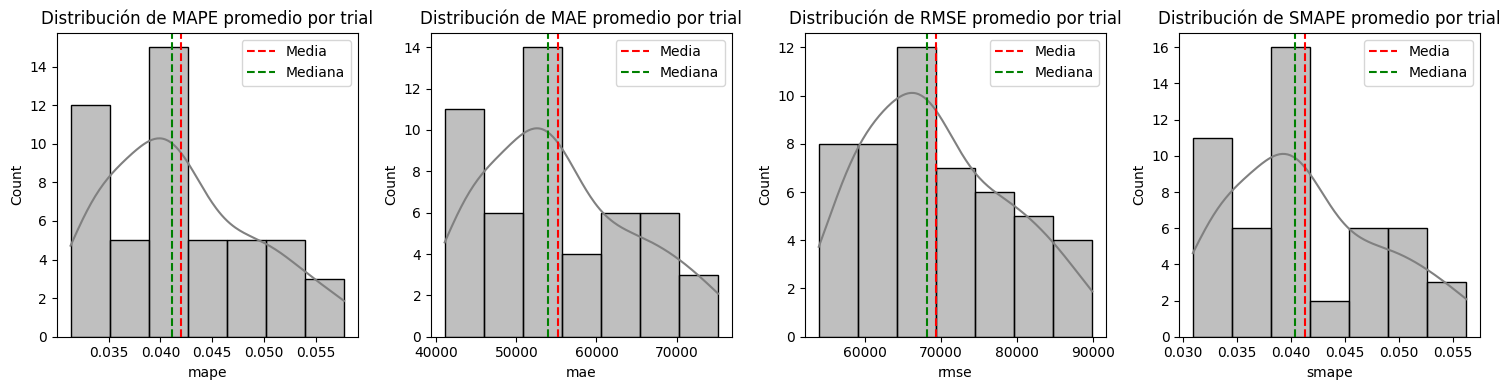

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics_avg[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()} promedio por trial")
    ax.axvline(df_metrics_avg[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics_avg[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()

### Distribución de errores por fold y por trial
se muestran los valores de las métricas de error por cada fold y por cada trial

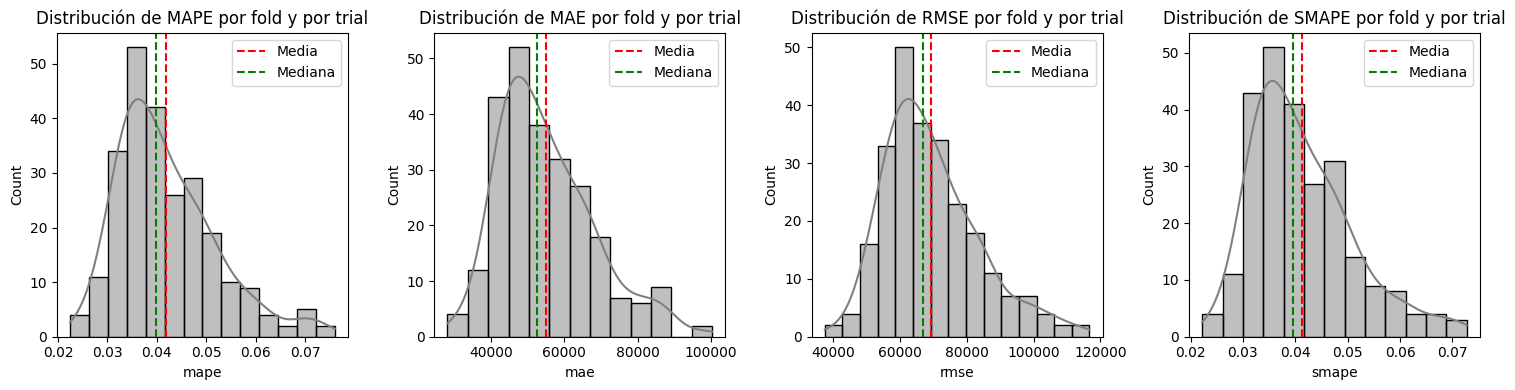

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, metric in zip(axes, ["mape", "mae", "rmse", "smape"]):
    sns.histplot(df_metrics[metric], kde=True, ax=ax, color="gray")
    ax.set_title(f"Distribución de {metric.upper()} por fold y por trial")
    ax.axvline(df_metrics[metric].mean(), color='red', linestyle='--', label='Media')
    ax.axvline(df_metrics[metric].median(), color='green', linestyle='--', label='Mediana')
    ax.legend()

plt.tight_layout()
plt.show()


se examinan errores de trials atipicos, se filtran los trials y los folds que tienen un mape mayor o igual al 10%

In [34]:
trials_atipicos = df_metrics[df_metrics["mape"] >= 0.1]
trials_atipicos.head()

,trial,fold,mape,mae,rmse,smape


In [35]:
params_trials_atipicos = []
for el in study.trials:
    if el.number in list(trials_atipicos["trial"].values):
        params_trials_atipicos.append({"params": el.params, "user_attrs": el.user_attrs, "trial": el.number})



for i in range(len(params_trials_atipicos)):
    avg_mape = 0
    params_trials_atipicos[i]["user_attrs"]
    for j in range(5):
        key = f'fold_{j+1}'

        avg_mape += params_trials_atipicos[i]['user_attrs'][key]['mape']
        print(f"mape {key} trial {params_trials_atipicos[i]['trial']}: {params_trials_atipicos[i]['user_attrs'][key]['mape']}")

    print(f"mape promedio trial {params_trials_atipicos[i]['trial']}: {avg_mape / 5} \n")


In [36]:
summary = df_metrics.groupby("trial")[["mape", "mae", "rmse", "smape"]].agg(["mean", "std"])
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.sort_values("mape_mean")
summary.head()


,mape_mean,mape_std,mae_mean,mae_std,rmse_mean,rmse_std,smape_mean,smape_std
trial,,,,,,,,
44,0.03,0.00,41044.67,5496.90,53960.67,7289.42,0.03,0.00
48,0.03,0.01,42108.48,13464.72,55908.75,17658.89,0.03,0.01
28,0.03,0.00,43223.23,5409.13,57234.88,5927.68,0.03,0.00
10,0.03,0.00,43955.09,4950.79,58353.34,7077.57,0.03,0.00
14,0.03,0.00,44222.49,3471.90,58019.87,4220.06,0.03,0.00


In [37]:
# validación

best_params = study.best_params

In [38]:
best_params

{'input_timesteps': 52,
 'units': 96,
 'lr': 0.0011178917527043502,
 'batch_size': 32,
 'epochs': 120,
 'dropout_rate': 0.033268680966822006,
 'recurrent_dropput_rate': 0.1041403772456473}

Se crea df que obtiene los hiperparametros por fold junto con las metricas asociadas, se toman los 3 que dejan menor mape promedio para comparar y luego se toma uno solo

In [39]:
df_trials = {
    "trial": [],
    "input_timesteps": [],
    "units": [],
    "lr": [],
    "epochs": [],
    "dropout_rate": [],
    "mape_mean": [],
    "mae_mean": [],
    "rmse_mean": [],
    "smape_mean": []
}

for trial in trials:
    for key in df_trials:

        if key == "trial":
            df_trials[key].append(trial.number)

        elif key in ["mape_mean", "smape_mean"]:
            value = trial.user_attrs.get(key, None)
            df_trials[key].append(
                float(f"{value * 100:.6f}") if value is not None else None
            )

        elif key in ["mae_mean", "rmse_mean"]:
            value = trial.user_attrs.get(key, None)
            df_trials[key].append(value)

        else:
            df_trials[key].append(trial.params.get(key, None))

trials_df = pd.DataFrame(df_trials).sort_values(by="mape_mean")
trials_df.head()

,trial,input_timesteps,units,lr,epochs,dropout_rate,mape_mean,mae_mean,rmse_mean,smape_mean
44,44,52,96,0.00,120,0.03,3.13,41044.67,53960.67,3.09
48,48,52,160,0.00,115,0.05,3.23,42108.48,55908.75,3.16
28,28,8,96,0.00,75,0.02,3.27,43223.23,57234.88,3.23
10,10,52,32,0.00,111,0.01,3.35,43955.09,58353.34,3.30
14,14,52,32,0.00,108,0.02,3.38,44222.49,58019.87,3.33


In [40]:
# se exporta el df anterior
# 
trials_df.head(3).to_csv("../../../data/best_train_models/best_models_rnn.csv")

Se realiza ahora la predicción sobre los datos de validación con el mejor conjunto de hiperparametros encontrado

In [41]:
# ventanas temporales optimas
L = best_params["input_timesteps"]

# datos de forma supervisada train
X_train, y_train = create_dataset(
    folds_data[features].values,
    folds_data[target].values.ravel(),
    L
) 

# test - se anexan los ultimos L registros de train para continuidad

combined = pd.concat(
    [folds_data.tail(L), val_data],
    axis=0
).reset_index(drop=True)

X_test_all, y_test_all = create_dataset(
    combined[features].values,
    combined[target].values.ravel(),
    L
)

X_val = X_test_all
y_val = y_test_all

print(f"len val_data: {len(val_data)}") 
print(f"len y_test: {len(y_test_all)}") 


len val_data: 58
len y_test: 58


In [42]:
print(f"len folds_data: {len(folds_data)}") 
print(f"len val_Data: {len(val_data)}") 

len folds_data: 517
len val_Data: 58


In [43]:
# ventanas temporales optimas
L = best_params["input_timesteps"]

# escalado 
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# se reescalan las features y el target (recordar que la RNN recibe todos los valores en [0,1])
n_features = X_train.shape[-1] # devuelve la longitud del array de mas adentro (la cantidad de variables-longitud de features)

X_train_rescaled = scaler_X.fit_transform(
    X_train.reshape(-1, n_features) #redimensiona un tensor de orden 3 en una matriz - porque el fit_transform recibe es una matriz
).reshape(X_train.shape)

X_test_rescaled = scaler_X.transform(
    X_val.reshape(-1, n_features)
).reshape(X_val.shape)

y_train_rescaled = scaler_y.fit_transform(
    y_train.reshape(-1,1)
)

# reproductibilidad modelo final
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
# se fija el modelo con los mejores hiperparametros encontrados
final_model = build_rnn(
    L,
    n_features,
    best_params["units"],
    best_params["lr"],
    dropout_rate=best_params["dropout_rate"],
    recurrent_dropout_rate=best_params["recurrent_dropput_rate"]
)

#early stop
early_stop = callbacks.EarlyStopping(
    monitor="loss",
    patience=10,
    restore_best_weights=True
)

# se fija el modelo a los datos de folds
final_model.fit(
    X_train_rescaled,
    y_train_rescaled,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    shuffle=False,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1186
Epoch 2/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0615
Epoch 3/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0404
Epoch 4/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0346
Epoch 5/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0401
Epoch 6/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0416
Epoch 7/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0378
Epoch 8/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0322
Epoch 9/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0335
Epoch 10/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0333
Epoch 11/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0310
Epoch 12/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0307
Epoch 13/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0309
Epoch 14/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0287
Epoch 15/120
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - lo

Se obtienen las predicciones y se calculan las métricas de error respecto a los datos de validación

In [44]:
y_true = val_data["value"].values
y_pred_scaled = final_model.predict(X_test_rescaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# métricas de error
smape_fn = MeanAbsolutePercentageError(symmetric=True)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = mean_absolute_percentage_error(y_true, y_pred)
smape = smape_fn(y_true, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape*100:.4f}%")
print(f"sMAPE: {smape*100:.4f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step
MAE: 38567.14129720853
RMSE: 50811.05937476897
MAPE: 2.9927%
sMAPE: 2.9934%


Se grafican los datos

In [46]:
len(y_true)

58

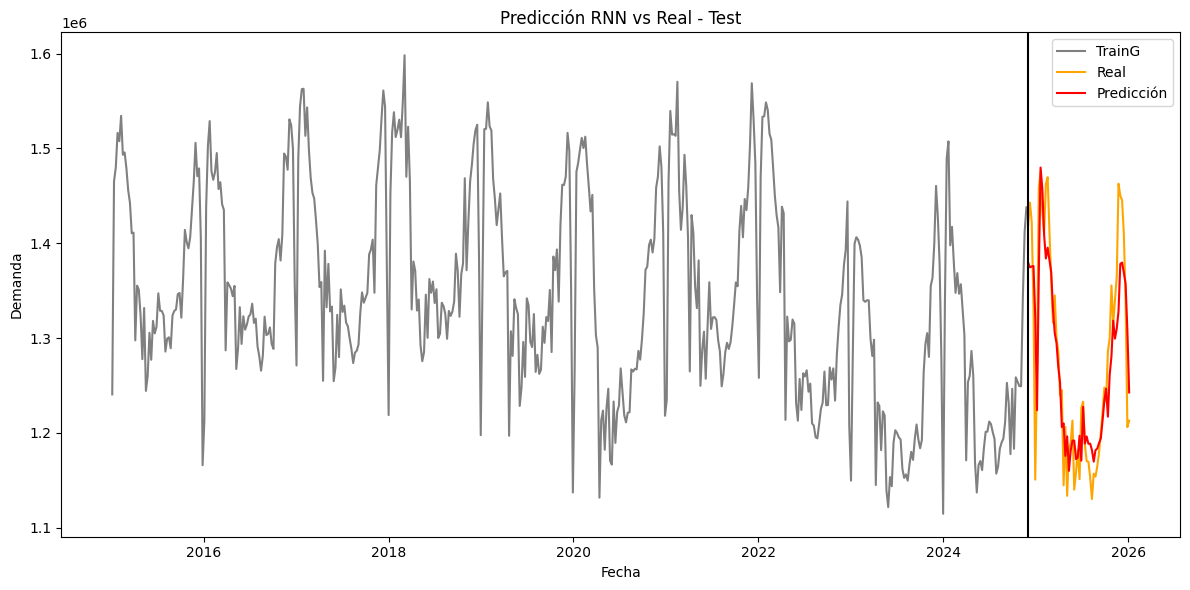

In [48]:
# Fechas reales del test

plt.figure(figsize=(12,6))
plt.plot(folds_data["Start date"], folds_data["value"], label="TrainG", color="gray")
plt.plot(val_data["Start date"], y_true, label="Real", color="orange")
plt.plot(val_data["Start date"], y_pred, label="Predicción", color='red')
#plt.plot(folds_data["Start date"], folds_data["value"].values, label="train", color='gray')
plt.axvline(start_val_data, color="black")
plt.title("Predicción RNN vs Real - Test")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.tight_layout()
plt.show()

Se exportan las predicciones en json para poder calcular luego la predicción conjunta


In [49]:
arr_preds = []
for index, value in enumerate(val_data["Start date"].values):
    dict_pred = {
        "Date": np.datetime_as_string(value, unit="D"), # convierte a la fecha a string para poder exportar a json
        "pred" : float(y_pred[index][0])
    }
    arr_preds.append(dict_pred)
arr_preds

[{'Date': '2024-12-02', 'pred': 1379474.625},
 {'Date': '2024-12-09', 'pred': 1374548.875},
 {'Date': '2024-12-16', 'pred': 1375478.375},
 {'Date': '2024-12-23', 'pred': 1375993.125},
 {'Date': '2024-12-30', 'pred': 1322380.25},
 {'Date': '2025-01-06', 'pred': 1223885.875},
 {'Date': '2025-01-13', 'pred': 1367524.75},
 {'Date': '2025-01-20', 'pred': 1479763.375},
 {'Date': '2025-01-27', 'pred': 1457192.75},
 {'Date': '2025-02-03', 'pred': 1408621.125},
 {'Date': '2025-02-10', 'pred': 1383910.875},
 {'Date': '2025-02-17', 'pred': 1395305.125},
 {'Date': '2025-02-24', 'pred': 1382289.5},
 {'Date': '2025-03-03', 'pred': 1369692.125},
 {'Date': '2025-03-10', 'pred': 1330715.375},
 {'Date': '2025-03-17', 'pred': 1305008.25},
 {'Date': '2025-03-24', 'pred': 1294623.5},
 {'Date': '2025-03-31', 'pred': 1269216.125},
 {'Date': '2025-04-07', 'pred': 1252780.875},
 {'Date': '2025-04-14', 'pred': 1206218.875},
 {'Date': '2025-04-21', 'pred': 1210068.75},
 {'Date': '2025-04-28', 'pred': 1175776.375

In [50]:
# Cálculo de métricas agregadas
dict_to_export = {
    "mape_val": float(mape),
    "mae_val": float(mae),
    "smape_val": float(smape),
    "rmse_val": float(rmse),
    "predictions": arr_preds
}
with open ("../../../data/preds_energy_models/rnn_preds.json", "w") as json_file:
    json.dump(dict_to_export, json_file, indent=4)

validacion adicional: se ejecuta varias veces el modelo final y se generan las predicciones con el fin de validar que los rangos de variación de las métricas de error sean consistentes

In [ ]:
# se fija el modelo a los datos de folds
n_iters = 10 # cantidad de veces en las que se instancia el modelo 
preds_dict = []

for i in range(n_iters):
    tf.keras.backend.clear_session()
    tf.random.set_seed(42)
    np.random.seed(42)

    model_iter = build_rnn(
        L, n_features,
        best_params["units"],
        best_params["lr"],
        dropout_rate=best_params["dropout_rate"],
        recurrent_dropout_rate=best_params["recurrent_dropput_rate"]
    )

    # se recrea el callback en cada iteración
    early_stop_iter = callbacks.EarlyStopping(
        monitor="loss",
        patience=10,
        restore_best_weights=True
    )

    model_iter.fit(
        X_train_rescaled, y_train_rescaled,
        epochs=best_params["epochs"],
        batch_size=best_params["batch_size"],
        shuffle=False,
        verbose=0,
        callbacks=[early_stop_iter]  
    )
    

    # lista de predicciones 
    y_true = val_data["value"].values
    y_pred_scaled = model_iter.predict(X_test_rescaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # métricas de error
    smape_fn = MeanAbsolutePercentageError(symmetric=True)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    smape = smape_fn(y_true, y_pred)

    preds_dict.append({
        "iteracion": i,
        "mape": mape * 100,
        "rmse": rmse,
        "mae": mae,
        "smape": smape * 100,
        "preds": y_pred
    })

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


In [52]:
cols_df_preds = ["iteracion", "mape", "rmse", "mae", "smape"]
arr_iteracion = [el["iteracion"] for el in preds_dict]
mape_iteracion = [el["mape"] for el in preds_dict]
mae_iteracion = [el["mae"] for el in preds_dict]
rmse_iteracion = [el["rmse"] for el in preds_dict]
smape_iteracion = [el["smape"] for el in preds_dict]


dataframe = pd.DataFrame(columns=cols_df_preds )
dataframe["iteracion"] = arr_iteracion
dataframe["mape"] = mape_iteracion
dataframe["mae"] = mae_iteracion
dataframe["rmse"] = rmse_iteracion
dataframe["smape"] = smape_iteracion
dataframe

,iteracion,mape,rmse,mae,smape
0,0,2.84,49477.32,36560.35,2.84
1,1,3.04,52142.91,39521.69,3.06
2,2,2.82,48515.65,36206.26,2.80
3,3,2.72,46220.87,34825.30,2.72
4,4,2.87,49397.71,37075.33,2.88
5,5,2.76,46172.94,35469.79,2.77
6,6,2.58,43192.41,32758.95,2.57
7,7,3.29,56739.89,43158.12,3.34
8,8,3.01,50785.09,38780.44,2.99
9,9,2.85,48203.92,36771.84,2.86
